# Pruebas de Ablación sobre las Características finales del Dataset

### Importación de Módulos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import json
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, log_loss
from scipy.sparse import csr_matrix, hstack
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

c:\Programacion\TFM Predicción Combates Pokémon\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Carga de datasets y json descriptor de características incluidas en las fases de las pruebas de ablación. 

In [2]:
df_ablation = pd.read_csv("../data/gen9ou_ablation_tests_dataset.csv")
df_ablation.head()

,battle_id,p1_poke1,p1_poke2,p1_poke3,p1_poke4,p1_poke5,p1_poke6,p2_poke1,p2_poke2,p2_poke3,...,diff_p1_min_Defense,diff_p1_mean_Sp. Atk,diff_p1_max_Sp. Atk,diff_p1_min_Sp. Atk,diff_p1_mean_Sp. Def,diff_p1_max_Sp. Def,diff_p1_min_Sp. Def,diff_p1_mean_Speed,diff_p1_max_Speed,diff_p1_min_Speed
0,83362-gen9ou-2484742250,Krookodile,Kommo-o,Araquanid,Inteleon,Noivern,Muk-Alola,Alomomola,Slowking-Galar,Corviknight,...,-15.0,-2.833333,-11.0,10.0,4.000000,22.0,20.0,23.166667,21.0,13.0
1,gen9ou-2008544089,Ninetales-Alola,Manaphy,Kommo-o,Iron Valiant,Samurott-Hisui,Kingambit,Pawmot,Samurott-Hisui,Toxapex,...,5.0,8.166667,-5.0,7.0,1.833333,-37.0,7.0,10.666667,7.0,15.0
2,gen9ou-2032727153,Serperior,Darkrai,Zapdos,Dragapult,Iron Valiant,Kingambit,Cresselia,Garganacl,Blissey,...,65.0,42.500000,60.0,20.0,-7.500000,-40.0,0.0,49.333333,57.0,15.0
3,gen9ou-2301833199,Ogerpon-Wellspring,Gholdengo,Glimmora,Raging Bolt,Iron Moth,Dragonite,Pelipper,Talonflame,Barraskewda,...,0.0,23.833333,15.0,0.0,17.500000,10.0,31.0,-4.500000,-26.0,30.0
4,gen9ou-2346353253,Garchomp,Slowking-Galar,Gholdengo,Moltres,Iron Valiant,Kingambit,Ceruledge,Rillaboom,Hatterene,...,5.0,31.666667,-3.0,7.0,7.833333,7.0,7.0,0.500000,-2.0,1.0


Se define la fracción de datos de entrenamiento a usar para el modelo Random Forest, dado que consume más recursos que el modelo LGBM. Además, se define el número de trials de Optuna.

In [3]:
rf_train_fraction = 0.15
n_trials = 5

In [4]:
test_ids = pd.read_csv("../splits/test_ids.csv")
train_ids = pd.read_csv("../splits/train_ids.csv")
val_ids = pd.read_csv("../splits/val_ids.csv")

rf_train_ids = np.random.choice(
    train_ids["battle_id"].values,
    size=int(len(train_ids["battle_id"].values) * rf_train_fraction),
    replace=False
)

In [5]:
df_train = df_ablation[df_ablation["battle_id"].isin(train_ids["battle_id"])].reset_index(drop=True)
df_val = df_ablation[df_ablation["battle_id"].isin(val_ids["battle_id"])].reset_index(drop=True)
df_test = df_ablation[df_ablation["battle_id"].isin(test_ids["battle_id"])].reset_index(drop=True)
df_train_rf = df_train[df_train["battle_id"].isin(rf_train_ids)]

In [6]:
features_groups = json.load(open("../json/feature_groups.json", "r"))

### Definición de Funciones de construcción de conjunto de datos

#### Definición de función construcción de represenación diferencial

In [7]:
from scipy.sparse import coo_matrix
import numpy as np

def build_team_differential(df, pokemon_to_idx):
    n_pokemon = len(pokemon_to_idx)
    
    rows = []
    cols = []
    data = []
    
    y = df['p1_win'].values
    
    for row_idx, row in enumerate(df.itertuples(index=False)):
        # team 1: +1
        for p in [row.p1_poke1, row.p1_poke2, row.p1_poke3, row.p1_poke4, row.p1_poke5, row.p1_poke6]:
            cols.append(pokemon_to_idx[p])
            rows.append(row_idx)
            data.append(1)
        
        # team 2: -1
        for p in [row.p2_poke1, row.p2_poke2, row.p2_poke3, row.p2_poke4, row.p2_poke5, row.p2_poke6]:
            cols.append(pokemon_to_idx[p])
            rows.append(row_idx)
            data.append(-1)
    
    # Construimos la matriz en formato COO
    X_coo = coo_matrix((data, (rows, cols)), shape=(len(df), n_pokemon), dtype=np.int8)
    
    # La convertimos internamente a formato CSR para que sea compatible con hstack y los modelos
    X = X_coo.tocsr()
    
    return X, y

In [8]:
def get_phase_columns(feature_groups, phase_groups):
    cols = []
    
    for group in phase_groups:
        cols.extend(feature_groups[group])
    
    return sorted(list(set(cols)))

función que añade características correspondientes a una fase a la matriz dispersa base, para mayor eficiencia.

In [9]:
def add_feature_group_to_matrix(
    X_current,
    df,
    feature_columns
):

    X_new = csr_matrix(
        df[feature_columns]
        .values
        .astype(np.float32)
    )

    return hstack([
        X_current,
        X_new
    ])

### Definición de Funciones de Optimización de Optuna para Random Forest y LightGBM

In [10]:
def objective_rf(trial, X_train, y_train, X_val, y_val):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),
        "n_jobs": -1,
        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, probs)

In [11]:
def objective_lgbm(trial, X_train, y_train, X_val, y_val):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "random_state": 42
    }

    model = lgb.LGBMClassifier(**params)

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, probs)

### Definición de Función de Optimización de Thresholds

In [12]:
def optimize_threshold(y_true, probs):

    thresholds = np.linspace(0.3, 0.7, 100)

    best_threshold = 0.5
    best_f1 = 0

    for thr in thresholds:

        preds = (probs >= thr).astype(int)

        score = f1_score(
            y_true,
            preds,
            average="macro"
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = thr

    return best_threshold, best_f1

### Definición de Función de Evaluación de Modelos

In [13]:
def evaluate_model(model, X, y, threshold):

    probs = model.predict_proba(X)[:, 1]

    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y, preds),
        "f1_macro": f1_score(y, preds, average="macro"),
        "roc_auc": roc_auc_score(y, probs),
        "log_loss": log_loss(y, probs),
        "confusion_matrix": confusion_matrix(y, preds).tolist()
    }

    return metrics

### Definición de Funciones de Persistencia de Modelos

In [14]:
def save_model_artifacts(
    model,
    metadata,
    params,
    model_name,
    phase_name
):

    base_name = f"{model_name}_{phase_name}_best_ablation_test"

    model_path = f"../models/{base_name}.joblib"
    metadata_path = f"../models/{base_name}.json"
    params_path = f"../parameters/{base_name}.json"

    joblib.dump(model, model_path)

    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(
            metadata,
            f,
            indent=4,
            ensure_ascii=False
        )

    with open(params_path, "w", encoding="utf-8") as f:
        json.dump(
            params,
            f,
            indent=4,
            ensure_ascii=False
        )

    print(f"Saved artifacts for {base_name}")

### Definición de Función Registro de Resultados

In [15]:
def append_results_to_csv(
    model_name,
    phase_name,
    metrics,
    csv_path="../results/ablation_results.csv"
):

    row = {
        "model": model_name,

        "phase": phase_name,

        "accuracy": metrics["accuracy"],

        "f1_macro": metrics["f1_macro"],

        "roc_auc": metrics["roc_auc"],

        "log_loss": metrics["log_loss"],

        "tn": metrics["confusion_matrix"][0][0],
        "fp": metrics["confusion_matrix"][0][1],
        "fn": metrics["confusion_matrix"][1][0],
        "tp": metrics["confusion_matrix"][1][1]
    }

    df_row = pd.DataFrame([row])

    if os.path.exists(csv_path):

        df_existing = pd.read_csv(csv_path)

        df_final = pd.concat(
            [df_existing, df_row],
            ignore_index=True
        )

    else:
        df_final = df_row

    df_final.to_csv(csv_path, index=False)

    print(f"Results appended to {csv_path}")

### Definición función Importancias

In [16]:
def save_and_plot_importances(state, phase_name, top_n=30, feature_names=None):
    """
    Extrae, grafica y guarda las importancias de las features para RF y LGBM.
    Guarda los resultados en ../importances/phase_{phase_name}/
    """
    rf_model = state["rf"]
    lgbm_model = state["lgbm"]


    n_features = rf_model.feature_importances_.shape[0]

    # --- DIAGNÓSTICO DE NOMBRES ---
    if feature_names is None:
        print(f"⚠️ NOTA: 'feature_names' recibidos es None. Usando nombres genéricos (Feature_0 a Feature_{n_features-1}).")
        feature_names = [f"Feature_{i}" for i in range(n_features)]
        
    elif len(feature_names) != n_features:
        print(f"❌ DESAJUSTE DETECTADO: El modelo tiene {n_features} features, pero has pasado una lista con {len(feature_names)} nombres.")
        print(f"   Revisa que estés acumulando 'current_feature_names = state[\"feature_names\"]' al final de cada fase.")
        print(f"   Activando nombres genéricos temporales para evitar un crash en esta celda.")
        feature_names = [f"Feature_{i}" for i in range(n_features)]
    else:
        print(f"Alineación perfecta: Se han mapeado correctamente los {n_features} nombres reales de las features.")
    
    output_dir = f"../importances/phase_{phase_name}"
    os.makedirs(output_dir, exist_ok=True)
    
        
    models = {
        "RandomForest": rf_model.feature_importances_,
        "LightGBM": lgbm_model.feature_importances_
    }
    
    for model_name, importances in models.items():
        # Crear DataFrame
        df_imp = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        
        # Ordenar de mayor a menor importancia
        df_imp = df_imp.sort_values(by="Importance", ascending=False).reset_index(drop=True)
        
        # Guardar el CSV con TODAS las features
        csv_path = os.path.join(output_dir, f"{model_name.lower()}_importances.csv")
        df_imp.to_csv(csv_path, index=False)
        
        # Graficar solo el Top N
        top_df = df_imp.head(top_n).copy()
        top_df = top_df.sort_values(by="Importance", ascending=True) # Invertir para que la mejor salga arriba en barh
        
        plt.figure(figsize=(10, 8))
        plt.barh(top_df["Feature"], top_df["Importance"], color="skyblue", edgecolor="black")
        plt.title(f"Top {top_n} Feature Importances - {model_name}\n(Fase: {phase_name})")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        
        # Guardar la imagen
        img_path = os.path.join(output_dir, f"{model_name.lower()}_top{top_n}.png")
        plt.savefig(img_path, dpi=300)
        plt.show()
        plt.close()
        
    print(f"✅ Importancias guardadas en: {output_dir}/")

### Función general de ejecución de pruebas de ablación

In [17]:
import time
import optuna
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier

def run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups,
    X_train_current,
    X_val_current,
    X_test_current,
    X_train_current_rf,
    current_feature_names,  
    y_train, 
    y_val, 
    y_test,
    y_train_rf,
    df_train,
    df_train_rf,
    df_val,
    df_test,
    n_trials=30,
    train_sample_fraction=1.0
):
    t_start = time.time()  # Tiempo total de la fase
    
    print("=" * 70)
    print(f"RUNNING ABLATION PHASE: {phase_name}")
    print(f"FEATURE GROUPS: {phase_sequence}")
    print("=" * 70)

    # 1. BUILD DENSE FEATURES FOR THIS PHASE
    t_step = time.time()
    feature_columns = []
    for group in phase_sequence:
        feature_columns.extend(feature_groups[group])

    feature_columns = sorted(list(set(feature_columns)))
    
    # IMPORTANTE: Combinamos los nombres previos con los nuevos en el mismo orden que el hstack
    all_feature_names = list(current_feature_names) + feature_columns
    
    print(f"New dense features added ({len(feature_columns)}): {feature_columns}")
    print(f"Total accumulated features: {len(all_feature_names)}")

    # SPLITS
    print("\nSplit sizes:")
    print(f"Train: {len(df_train)} | Train (RF sample): {len(df_train_rf)}")
    print(f"Validation: {len(df_val)} | Test: {len(df_test)}")

    # ADD FEATURES TO EXISTING MATRIX
    def add_dense(X_sparse, df):
        from scipy.sparse import hstack, csr_matrix
        vals = df[feature_columns].values.astype("float32")
        if vals.ndim == 1:
            vals = vals.reshape(-1, 1)
        X_dense = csr_matrix(vals)
        return hstack([X_sparse, X_dense])

    X_train = add_dense(X_train_current, df_train)
    X_val = add_dense(X_val_current, df_val)
    X_test = add_dense(X_test_current, df_test)
    X_train_rf = add_dense(X_train_current_rf, df_train_rf)

    # CORTAFUEGOS: Detiene el código si las matrices no son idénticas en anchura
    if X_train.shape[1] != X_train_rf.shape[1]:
        raise ValueError(f"CRÍTICO: X_train tiene {X_train.shape[1]} features, pero X_train_rf tiene {X_train_rf.shape[1]}. "
                         "Las matrices base fueron creadas de forma distinta. Corrige el preprocesamiento inicial.")

    print(f"\nMatrix shapes -> Train: {X_train.shape} | Val: {X_val.shape}")
    print(f"⏱️ [PASO 1] Construcción y apilado de features: {time.time() - t_step:.2f}s")

    # =====================================================
    # OPTUNA OPTIMIZATION
    # =====================================================
    print("\nStarting Optuna optimization...")
    
    # Optuna RF
    t_step = time.time()
    print("-> Optimizando Random Forest...")
    study_rf = optuna.create_study(direction="maximize")
    study_rf.optimize(
        lambda trial: objective_rf(trial, X_train_rf, y_train_rf, X_val, y_val),
        n_trials=n_trials
    )
    print(f"⏱️ [PASO 2A] Optuna Random Forest ({n_trials} trials): {time.time() - t_step:.2f}s")

    # Optuna LGBM
    t_step = time.time()
    print("-> Optimizando LightGBM...")
    study_lgbm = optuna.create_study(direction="maximize")
    study_lgbm.optimize(
        lambda trial: objective_lgbm(trial, X_train, y_train, X_val, y_val),
        n_trials=n_trials
    )
    print(f"⏱️ [PASO 2B] Optuna LightGBM ({n_trials} trials): {time.time() - t_step:.2f}s")

    print(f"\nBest validation ROC-AUC RF: {study_rf.best_value:.5f}")
    print(f"Best validation ROC-AUC LGBM: {study_lgbm.best_value:.5f}")

    # =====================================================
    # FINAL TRAINING
    # =====================================================
    print("\nTraining final models with best parameters...")

    # RF
    t_step = time.time()
    rf = RandomForestClassifier(**study_rf.best_params, n_jobs=-1, random_state=42)
    rf.fit(X_train_rf, y_train_rf)
    print(f"⏱️ [PASO 3A] Entrenamiento final Random Forest: {time.time() - t_step:.2f}s")
    
    # LGBM
    t_step = time.time()
    lgbm = lgb.LGBMClassifier(
        **study_lgbm.best_params,
        objective="binary",
        metric="auc",
        verbosity=-1,
        random_state=42
    )
    lgbm.fit(X_train, y_train)
    print(f"⏱️ [PASO 3B] Entrenamiento final LightGBM: {time.time() - t_step:.2f}s")

    # =====================================================
    # THRESHOLD OPTIMIZATION
    # =====================================================
    t_step = time.time()
    print("\nOptimizing classification threshold...")
    rf_val = rf.predict_proba(X_val)[:, 1]
    lgbm_val = lgbm.predict_proba(X_val)[:, 1]

    rf_thr, rf_f1 = optimize_threshold(y_val, rf_val)
    lgbm_thr, lgbm_f1 = optimize_threshold(y_val, lgbm_val)

    print(f"Best threshold RF: {rf_thr:.5f} (F1: {rf_f1:.5f})")
    print(f"Best threshold LGBM: {lgbm_thr:.5f} (F1: {lgbm_f1:.5f})")
    print(f"⏱️ [PASO 4] Optimización de Thresholds: {time.time() - t_step:.2f}s")

    # =====================================================
    # FINAL TEST EVALUATION & ARTIFACTS
    # =====================================================
    t_step = time.time()
    print("\nEvaluating on test set and saving results...")
    rf_metrics = evaluate_model(rf, X_test, y_test, rf_thr)
    lgbm_metrics = evaluate_model(lgbm, X_test, y_test, lgbm_thr)

    

    def build_metadata(model_name, study, thr, metrics):
        return {
            "model": model_name, "phase": phase_name, "feature_groups": phase_sequence,
            "representation": "team_differential", "dataset": "gen9ou_final_dataset",
            "n_features": int(X_train.shape[1]), "metric": "roc_auc",
            "validation_best_score": float(study.best_value), "best_threshold": float(thr),
            "threshold_metric": "f1_macro", "threshold_range": [0.3, 0.7], "params": study.best_params,
            "test_metrics": {
                "accuracy": float(metrics["accuracy"]), "f1_macro": float(metrics["f1_macro"]),
                "roc_auc": float(metrics["roc_auc"]), "log_loss": float(metrics["log_loss"]),
                "confusion_matrix": metrics["confusion_matrix"].tolist() if hasattr(metrics["confusion_matrix"], "tolist") else metrics["confusion_matrix"]
            },
            "rf_train_fraction": train_sample_fraction
        }

    rf_metadata = build_metadata("RandomForest", study_rf, rf_thr, rf_metrics)
    lgbm_metadata = build_metadata("LightGBM", study_lgbm, lgbm_thr, lgbm_metrics)

    save_model_artifacts(rf, rf_metadata, study_rf.best_params, "rf", phase_name)
    save_model_artifacts(lgbm, lgbm_metadata, study_lgbm.best_params, "lgbm", phase_name)
    append_results_to_csv("rf", phase_name, rf_metrics)
    append_results_to_csv("lgbm", phase_name, lgbm_metrics)
    
    print(f"⏱️ [PASO 5] Evaluación y guardado de artefactos: {time.time() - t_step:.2f}s")
    print(f"\n🚀 FASE COMPLETADA EN: {time.time() - t_start:.2f} segundos (~{((time.time() - t_start)/60):.2f} minutos)")
    print("=" * 70)

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_rf": X_train_rf,
        "rf": rf,
        "lgbm": lgbm,
        "rf_metadata": rf_metadata,
        "lgbm_metadata": lgbm_metadata,
        "feature_names": all_feature_names
    }

### Generación de matrices dispersas base

In [18]:
pokemon_cols = [
    "p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6",
    "p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"
]

all_pokemon = pd.unique(df_ablation[pokemon_cols].values.ravel())

pokemon_to_idx = {p: i for i, p in enumerate(sorted(all_pokemon))}
n_pokemon = len(pokemon_to_idx)

In [19]:
idx_to_pokemon = {idx: name for name, idx in pokemon_to_idx.items()}

current_feature_names = [f"PKMN_{idx_to_pokemon[i]}" for i in range(len(pokemon_to_idx))]
print(f"✅ Nombres base inicializados. Total features base (Pokémon): {len(current_feature_names)}")
print(f"Ejemplo primeros 5: {current_feature_names[:5]}")

✅ Nombres base inicializados. Total features base (Pokémon): 789
Ejemplo primeros 5: ['PKMN_Abomasnow', 'PKMN_Aipom', 'PKMN_Alcremie', 'PKMN_Alomomola', 'PKMN_Altaria']


In [20]:
X_train_sparse, y_train = build_team_differential(df_train, pokemon_to_idx)

X_val_sparse, y_val = build_team_differential(df_val, pokemon_to_idx)

X_test_sparse, y_test = build_team_differential(df_test, pokemon_to_idx)

rf_mask = df_train["battle_id"].isin(rf_train_ids).values

X_train_sparse_rf = X_train_sparse[rf_mask].copy()
y_train_rf = y_train[rf_mask].copy()

## FASE 1: Solo características de los Pokémon

In [21]:
phase_name = "basic_stats"
phase_sequence = ["basic_stats"]

In [22]:
state = run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups=features_groups,
    X_train_current=X_train_sparse,
    X_val_current=X_val_sparse,
    X_test_current=X_test_sparse,
    X_train_current_rf=X_train_sparse_rf,
    current_feature_names=current_feature_names,
    y_train=y_train, 
    y_val=y_val, 
    y_test=y_test,
    y_train_rf=y_train_rf,
    df_train=df_train,
    df_train_rf=df_train_rf,
    df_val=df_val,
    df_test=df_test,
    n_trials=n_trials,
    train_sample_fraction=rf_train_fraction
)

RUNNING ABLATION PHASE: basic_stats
FEATURE GROUPS: ['basic_stats']
New dense features added (72): ['Attack_p1_1', 'Attack_p1_2', 'Attack_p1_3', 'Attack_p1_4', 'Attack_p1_5', 'Attack_p1_6', 'Attack_p2_1', 'Attack_p2_2', 'Attack_p2_3', 'Attack_p2_4', 'Attack_p2_5', 'Attack_p2_6', 'Defense_p1_1', 'Defense_p1_2', 'Defense_p1_3', 'Defense_p1_4', 'Defense_p1_5', 'Defense_p1_6', 'Defense_p2_1', 'Defense_p2_2', 'Defense_p2_3', 'Defense_p2_4', 'Defense_p2_5', 'Defense_p2_6', 'HP_p1_1', 'HP_p1_2', 'HP_p1_3', 'HP_p1_4', 'HP_p1_5', 'HP_p1_6', 'HP_p2_1', 'HP_p2_2', 'HP_p2_3', 'HP_p2_4', 'HP_p2_5', 'HP_p2_6', 'Sp. Atk_p1_1', 'Sp. Atk_p1_2', 'Sp. Atk_p1_3', 'Sp. Atk_p1_4', 'Sp. Atk_p1_5', 'Sp. Atk_p1_6', 'Sp. Atk_p2_1', 'Sp. Atk_p2_2', 'Sp. Atk_p2_3', 'Sp. Atk_p2_4', 'Sp. Atk_p2_5', 'Sp. Atk_p2_6', 'Sp. Def_p1_1', 'Sp. Def_p1_2', 'Sp. Def_p1_3', 'Sp. Def_p1_4', 'Sp. Def_p1_5', 'Sp. Def_p1_6', 'Sp. Def_p2_1', 'Sp. Def_p2_2', 'Sp. Def_p2_3', 'Sp. Def_p2_4', 'Sp. Def_p2_5', 'Sp. Def_p2_6', 'Speed_p1_1'

[I 2026-05-23 19:01:29,437] A new study created in memory with name: no-name-25b7268b-03bc-46cd-9c45-09332573419a



Matrix shapes -> Train: (1127573, 861) | Val: (281894, 861)
⏱️ [PASO 1] Construcción y apilado de features: 8.01s

Starting Optuna optimization...
-> Optimizando Random Forest...


[I 2026-05-23 19:03:49,559] Trial 0 finished with value: 0.5530027172409998 and parameters: {'n_estimators': 605, 'max_depth': 26, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5530027172409998.
[I 2026-05-23 19:06:54,451] Trial 1 finished with value: 0.552556774081809 and parameters: {'n_estimators': 896, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5530027172409998.
[I 2026-05-23 19:10:04,237] Trial 2 finished with value: 0.5488924888974854 and parameters: {'n_estimators': 311, 'max_depth': 19, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5530027172409998.
[I 2026-05-23 19:15:50,103] Trial 3 finished with value: 0.5511653061753736 and parameters: {'n_estimators': 498, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5530027172409

⏱️ [PASO 2A] Optuna Random Forest (5 trials): 1164.17s
-> Optimizando LightGBM...


[I 2026-05-23 19:22:01,929] Trial 0 finished with value: 0.5660244482684818 and parameters: {'n_estimators': 893, 'learning_rate': 0.019229551063179622, 'num_leaves': 170, 'max_depth': 7, 'min_child_samples': 89, 'subsample': 0.9747368490922897, 'colsample_bytree': 0.8734181033228984}. Best is trial 0 with value: 0.5660244482684818.
[I 2026-05-23 19:23:20,138] Trial 1 finished with value: 0.5764899494254208 and parameters: {'n_estimators': 609, 'learning_rate': 0.03959123546072695, 'num_leaves': 175, 'max_depth': 30, 'min_child_samples': 92, 'subsample': 0.9761001318420046, 'colsample_bytree': 0.7520663708932505}. Best is trial 1 with value: 0.5764899494254208.
[I 2026-05-23 19:24:49,043] Trial 2 finished with value: 0.57500869611095 and parameters: {'n_estimators': 547, 'learning_rate': 0.021839614558194092, 'num_leaves': 230, 'max_depth': 17, 'min_child_samples': 19, 'subsample': 0.8103364654516345, 'colsample_bytree': 0.7055147592135396}. Best is trial 1 with value: 0.57648994942542

⏱️ [PASO 2B] Optuna LightGBM (5 trials): 347.09s

Best validation ROC-AUC RF: 0.55300
Best validation ROC-AUC LGBM: 0.57649

Training final models with best parameters...
⏱️ [PASO 3A] Entrenamiento final Random Forest: 136.40s
⏱️ [PASO 3B] Entrenamiento final LightGBM: 73.53s

Optimizing classification threshold...
Best threshold RF: 0.50202 (F1: 0.53591)
Best threshold LGBM: 0.50202 (F1: 0.55341)
⏱️ [PASO 4] Optimización de Thresholds: 16.65s

Evaluating on test set and saving results...
Saved artifacts for rf_basic_stats_best_ablation_test
Saved artifacts for lgbm_basic_stats_best_ablation_test
Results appended to ../results/ablation_results.csv
Results appended to ../results/ablation_results.csv
⏱️ [PASO 5] Evaluación y guardado de artefactos: 16.84s

🚀 FASE COMPLETADA EN: 1762.70 segundos (~29.38 minutos)


Alineación perfecta: Se han mapeado correctamente los 861 nombres reales de las features.


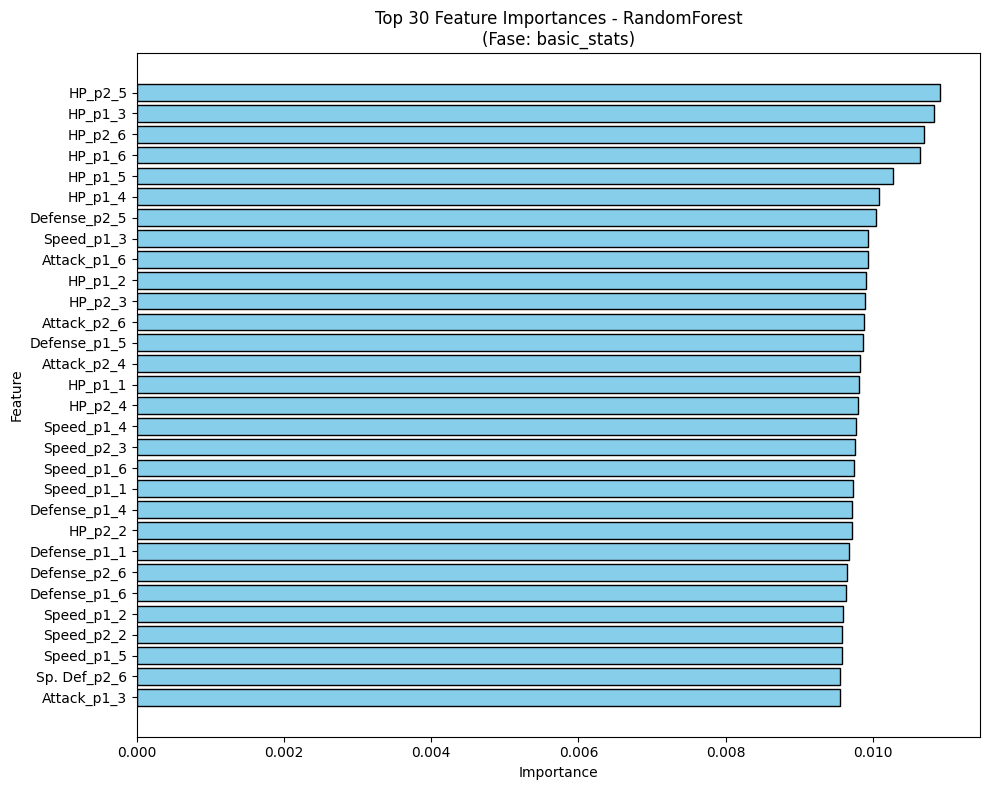

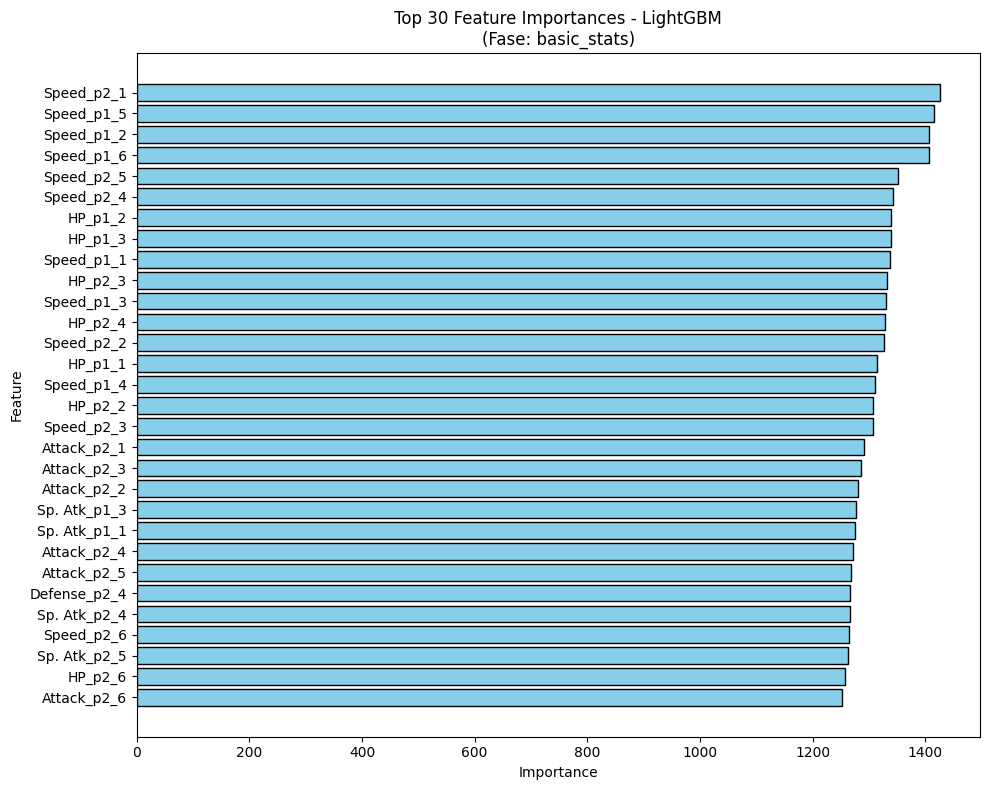

✅ Importancias guardadas en: ../importances/phase_basic_stats/


In [23]:
current_feature_names = state["feature_names"]
save_and_plot_importances(state, phase_name, top_n=30, feature_names=current_feature_names)

In [24]:
X_train_current = state["X_train"]
X_val_current = state["X_val"]
X_test_current = state["X_test"]
X_train_current_rf = state["X_train_rf"]

## FASE 2: Estadísticas diferenciales básicas

In [25]:
phase_name = "basic_diff_stats"
phase_sequence = ["basic_diff_stats"]

In [26]:
state = run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups=features_groups,
    X_train_current=X_train_current,
    X_val_current=X_val_current,
    X_test_current=X_test_current,
    X_train_current_rf=X_train_current_rf,
    current_feature_names=current_feature_names,
    y_train=y_train, 
    y_val=y_val, 
    y_test=y_test,
    y_train_rf=y_train_rf,
    df_train=df_train,
    df_train_rf=df_train_rf,
    df_val=df_val,
    df_test=df_test,
    n_trials=n_trials,
    train_sample_fraction=rf_train_fraction
)

RUNNING ABLATION PHASE: basic_diff_stats
FEATURE GROUPS: ['basic_diff_stats']
New dense features added (18): ['diff_p1_max_Attack', 'diff_p1_max_Defense', 'diff_p1_max_HP', 'diff_p1_max_Sp. Atk', 'diff_p1_max_Sp. Def', 'diff_p1_max_Speed', 'diff_p1_mean_Attack', 'diff_p1_mean_Defense', 'diff_p1_mean_HP', 'diff_p1_mean_Sp. Atk', 'diff_p1_mean_Sp. Def', 'diff_p1_mean_Speed', 'diff_p1_min_Attack', 'diff_p1_min_Defense', 'diff_p1_min_HP', 'diff_p1_min_Sp. Atk', 'diff_p1_min_Sp. Def', 'diff_p1_min_Speed']
Total accumulated features: 879

Split sizes:
Train: 1127573 | Train (RF sample): 169135
Validation: 281894 | Test: 352367


[I 2026-05-23 19:30:49,740] A new study created in memory with name: no-name-ee82d165-73c4-49ce-8f81-afbbb3b315bf



Matrix shapes -> Train: (1127573, 879) | Val: (281894, 879)
⏱️ [PASO 1] Construcción y apilado de features: 3.30s

Starting Optuna optimization...
-> Optimizando Random Forest...


[I 2026-05-23 19:31:17,285] Trial 0 finished with value: 0.5442495451641556 and parameters: {'n_estimators': 250, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5442495451641556.
[I 2026-05-23 19:45:50,040] Trial 1 finished with value: 0.5519476449115321 and parameters: {'n_estimators': 829, 'max_depth': 29, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5519476449115321.
[I 2026-05-23 19:53:09,885] Trial 2 finished with value: 0.5482482215869853 and parameters: {'n_estimators': 296, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5519476449115321.
[I 2026-05-23 19:54:43,954] Trial 3 finished with value: 0.5443494625287864 and parameters: {'n_estimators': 377, 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.551947644911

⏱️ [PASO 2A] Optuna Random Forest (5 trials): 1498.77s
-> Optimizando LightGBM...


[I 2026-05-23 19:56:27,742] Trial 0 finished with value: 0.5657656894214687 and parameters: {'n_estimators': 384, 'learning_rate': 0.16833963242672176, 'num_leaves': 153, 'max_depth': 33, 'min_child_samples': 44, 'subsample': 0.8957509954079479, 'colsample_bytree': 0.9956823073615431}. Best is trial 0 with value: 0.5657656894214687.
[I 2026-05-23 19:58:34,077] Trial 1 finished with value: 0.5770982344358706 and parameters: {'n_estimators': 651, 'learning_rate': 0.02518457379854657, 'num_leaves': 246, 'max_depth': 36, 'min_child_samples': 87, 'subsample': 0.6154695021075621, 'colsample_bytree': 0.7984900938922876}. Best is trial 1 with value: 0.5770982344358706.
[I 2026-05-23 19:59:44,392] Trial 2 finished with value: 0.5582400491105911 and parameters: {'n_estimators': 964, 'learning_rate': 0.016730333755438, 'num_leaves': 136, 'max_depth': 5, 'min_child_samples': 83, 'subsample': 0.760861262668083, 'colsample_bytree': 0.6474323935120937}. Best is trial 1 with value: 0.5770982344358706.

⏱️ [PASO 2B] Optuna LightGBM (5 trials): 420.39s

Best validation ROC-AUC RF: 0.55195
Best validation ROC-AUC LGBM: 0.57711

Training final models with best parameters...
⏱️ [PASO 3A] Entrenamiento final Random Forest: 853.99s
⏱️ [PASO 3B] Entrenamiento final LightGBM: 97.22s

Optimizing classification threshold...
Best threshold RF: 0.50202 (F1: 0.53564)
Best threshold LGBM: 0.50202 (F1: 0.55336)
⏱️ [PASO 4] Optimización de Thresholds: 30.96s

Evaluating on test set and saving results...
Saved artifacts for rf_basic_diff_stats_best_ablation_test
Saved artifacts for lgbm_basic_diff_stats_best_ablation_test
Results appended to ../results/ablation_results.csv
Results appended to ../results/ablation_results.csv
⏱️ [PASO 5] Evaluación y guardado de artefactos: 34.56s

🚀 FASE COMPLETADA EN: 2939.20 segundos (~48.99 minutos)


Alineación perfecta: Se han mapeado correctamente los 879 nombres reales de las features.


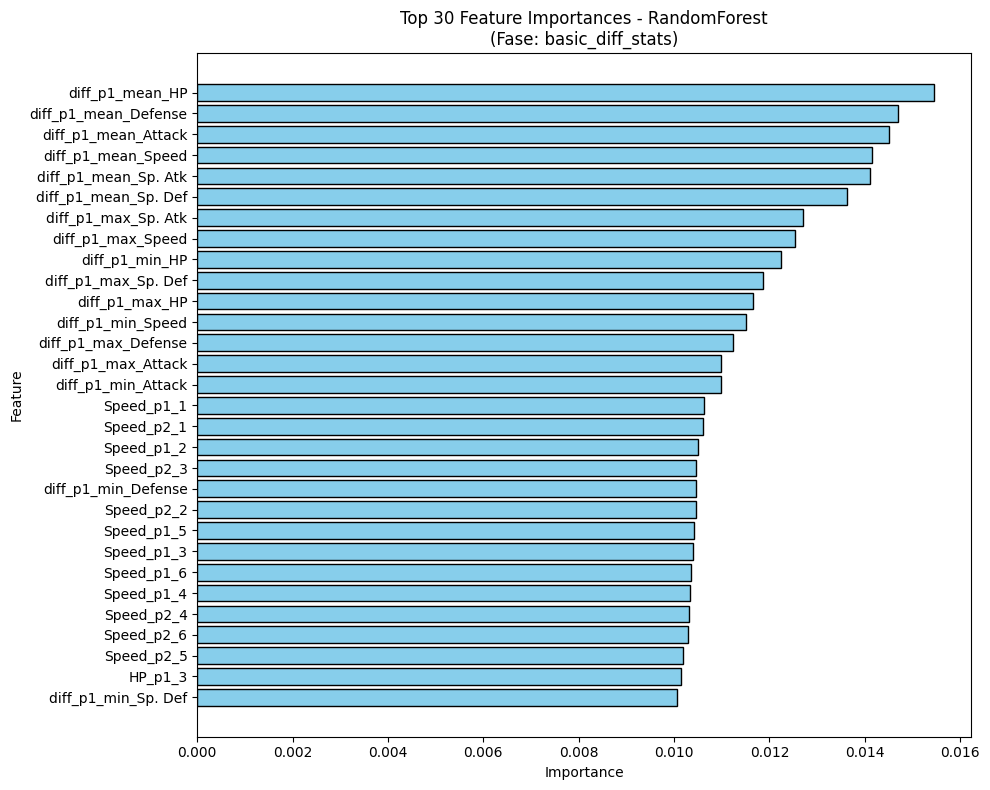

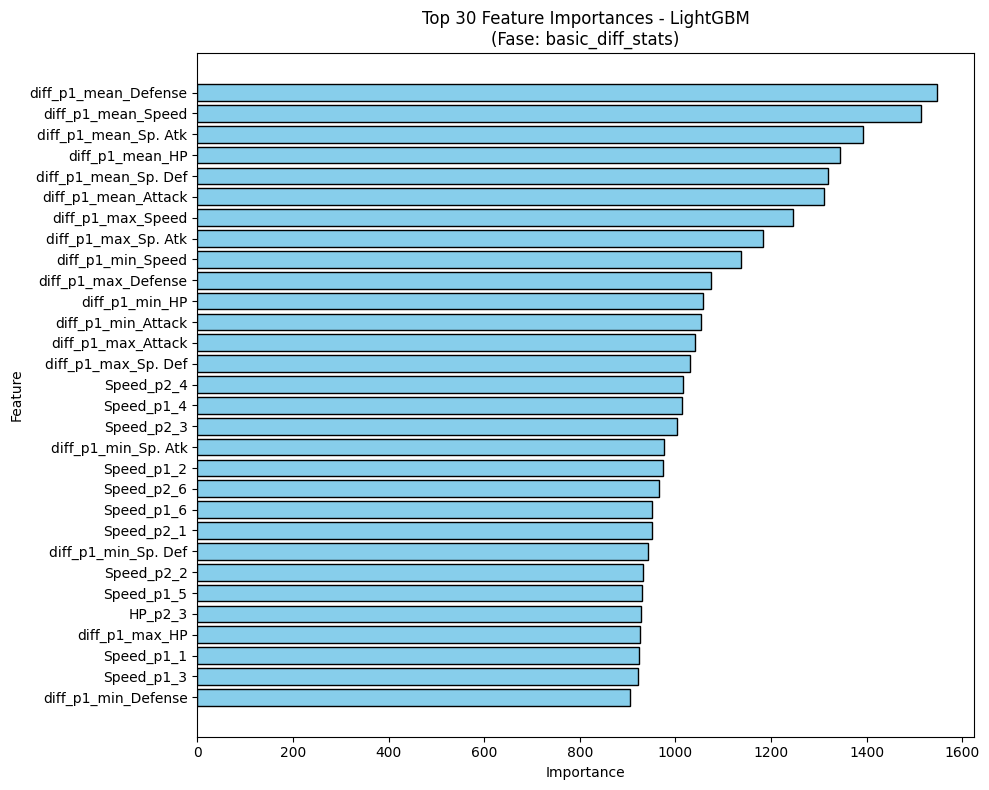

✅ Importancias guardadas en: ../importances/phase_basic_diff_stats/


In [27]:
current_feature_names = state["feature_names"]
save_and_plot_importances(state, phase_name, top_n=30, feature_names=current_feature_names)

In [28]:
X_train_current = state["X_train"]
X_val_current = state["X_val"]
X_test_current = state["X_test"]
X_train_current_rf = state["X_train_rf"]

## FASE 3: Estadísticas calculadas avanzadas

In [29]:
phase_name = "pokemon_engineered"
phase_sequence = ["pokemon_engineered"]

In [30]:
state = run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups=features_groups,
    X_train_current=X_train_current,
    X_val_current=X_val_current,
    X_test_current=X_test_current,
    X_train_current_rf=X_train_current_rf,
    current_feature_names=current_feature_names,
    y_train=y_train, 
    y_val=y_val, 
    y_test=y_test,
    y_train_rf=y_train_rf,
    df_train=df_train,
    df_train_rf=df_train_rf,
    df_val=df_val,
    df_test=df_test,
    n_trials=n_trials,
    train_sample_fraction=rf_train_fraction
)

RUNNING ABLATION PHASE: pokemon_engineered
FEATURE GROUPS: ['pokemon_engineered']
New dense features added (72): ['fast_offense_p1_1', 'fast_offense_p1_2', 'fast_offense_p1_3', 'fast_offense_p1_4', 'fast_offense_p1_5', 'fast_offense_p1_6', 'fast_offense_p2_1', 'fast_offense_p2_2', 'fast_offense_p2_3', 'fast_offense_p2_4', 'fast_offense_p2_5', 'fast_offense_p2_6', 'mixed_bulk_p1_1', 'mixed_bulk_p1_2', 'mixed_bulk_p1_3', 'mixed_bulk_p1_4', 'mixed_bulk_p1_5', 'mixed_bulk_p1_6', 'mixed_bulk_p2_1', 'mixed_bulk_p2_2', 'mixed_bulk_p2_3', 'mixed_bulk_p2_4', 'mixed_bulk_p2_5', 'mixed_bulk_p2_6', 'offense_bias_p1_1', 'offense_bias_p1_2', 'offense_bias_p1_3', 'offense_bias_p1_4', 'offense_bias_p1_5', 'offense_bias_p1_6', 'offense_bias_p2_1', 'offense_bias_p2_2', 'offense_bias_p2_3', 'offense_bias_p2_4', 'offense_bias_p2_5', 'offense_bias_p2_6', 'offense_p1_1', 'offense_p1_2', 'offense_p1_3', 'offense_p1_4', 'offense_p1_5', 'offense_p1_6', 'offense_p2_1', 'offense_p2_2', 'offense_p2_3', 'offense_p

[I 2026-05-23 20:20:00,168] A new study created in memory with name: no-name-1478d208-80bc-4103-a73d-2ff1e4b6d197



Matrix shapes -> Train: (1127573, 951) | Val: (281894, 951)
⏱️ [PASO 1] Construcción y apilado de features: 12.49s

Starting Optuna optimization...
-> Optimizando Random Forest...


[I 2026-05-23 20:23:13,839] Trial 0 finished with value: 0.5493140354349698 and parameters: {'n_estimators': 434, 'max_depth': 29, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.5493140354349698.
[I 2026-05-23 20:28:48,514] Trial 1 finished with value: 0.550321983762768 and parameters: {'n_estimators': 473, 'max_depth': 31, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.550321983762768.
[I 2026-05-23 20:32:15,039] Trial 2 finished with value: 0.5492471027220966 and parameters: {'n_estimators': 352, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.550321983762768.
[I 2026-05-23 20:41:32,339] Trial 3 finished with value: 0.5487081121088739 and parameters: {'n_estimators': 693, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.550321983762768

⏱️ [PASO 2A] Optuna Random Forest (5 trials): 1900.50s
-> Optimizando LightGBM...


[I 2026-05-23 20:53:09,751] Trial 0 finished with value: 0.5705972280243213 and parameters: {'n_estimators': 428, 'learning_rate': 0.08015441391446826, 'num_leaves': 191, 'max_depth': 39, 'min_child_samples': 27, 'subsample': 0.9935350917549794, 'colsample_bytree': 0.7876181347713962}. Best is trial 0 with value: 0.5705972280243213.
[I 2026-05-23 20:54:20,828] Trial 1 finished with value: 0.5669643565591443 and parameters: {'n_estimators': 596, 'learning_rate': 0.175091617617679, 'num_leaves': 63, 'max_depth': 17, 'min_child_samples': 75, 'subsample': 0.8978555009602742, 'colsample_bytree': 0.8217593686961957}. Best is trial 0 with value: 0.5705972280243213.
[I 2026-05-23 20:58:03,471] Trial 2 finished with value: 0.5735754469492862 and parameters: {'n_estimators': 672, 'learning_rate': 0.019467098733502646, 'num_leaves': 206, 'max_depth': 34, 'min_child_samples': 32, 'subsample': 0.8685285903066986, 'colsample_bytree': 0.9495806195327706}. Best is trial 2 with value: 0.573575446949286

⏱️ [PASO 2B] Optuna LightGBM (5 trials): 610.25s

Best validation ROC-AUC RF: 0.55325
Best validation ROC-AUC LGBM: 0.57587

Training final models with best parameters...
⏱️ [PASO 3A] Entrenamiento final Random Forest: 576.50s
⏱️ [PASO 3B] Entrenamiento final LightGBM: 135.81s

Optimizing classification threshold...
Best threshold RF: 0.50202 (F1: 0.53672)
Best threshold LGBM: 0.50202 (F1: 0.55285)
⏱️ [PASO 4] Optimización de Thresholds: 35.62s

Evaluating on test set and saving results...
Saved artifacts for rf_pokemon_engineered_best_ablation_test
Saved artifacts for lgbm_pokemon_engineered_best_ablation_test
Results appended to ../results/ablation_results.csv
Results appended to ../results/ablation_results.csv
⏱️ [PASO 5] Evaluación y guardado de artefactos: 42.62s

🚀 FASE COMPLETADA EN: 3313.79 segundos (~55.23 minutos)


Alineación perfecta: Se han mapeado correctamente los 951 nombres reales de las features.


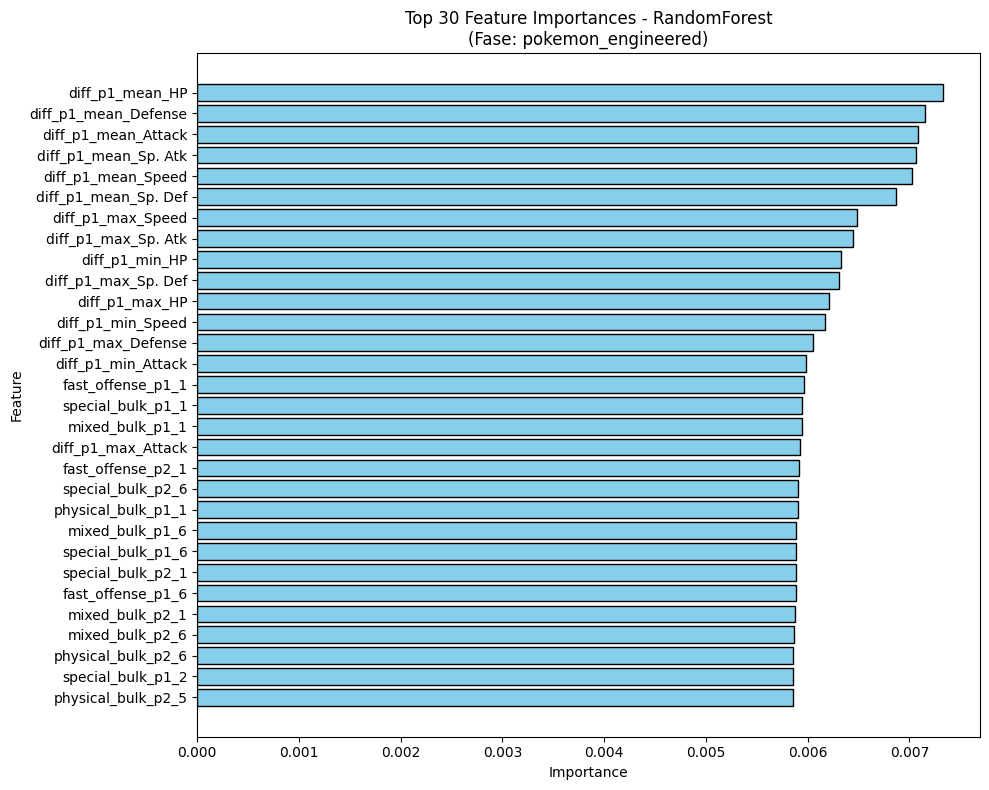

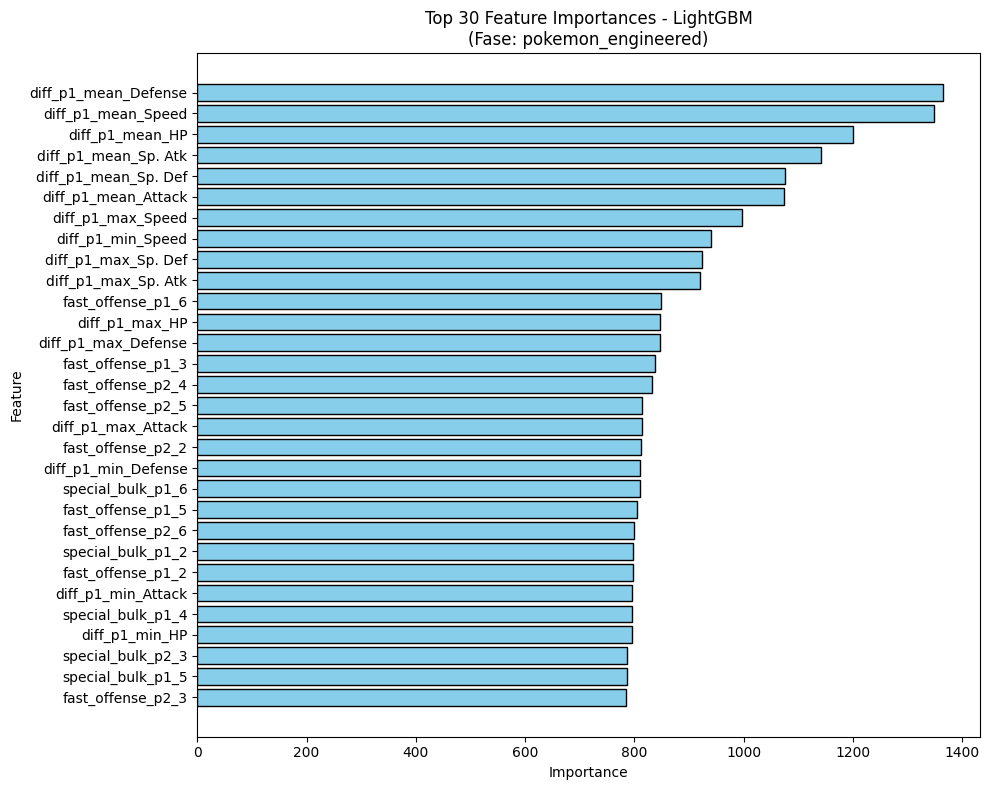

✅ Importancias guardadas en: ../importances/phase_pokemon_engineered/


In [31]:
current_feature_names = state["feature_names"]
save_and_plot_importances(state, phase_name, top_n=30, feature_names=current_feature_names)

In [32]:
X_train_current = state["X_train"]
X_val_current = state["X_val"]
X_test_current = state["X_test"]
X_train_current_rf = state["X_train_rf"]
current_feature_names = state["feature_names"]

## FASE 4: Roles Pokémon

In [33]:
phase_name = "team_roles"
phase_sequence = ["team_roles"]

In [34]:
state = run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups=features_groups,
    X_train_current=X_train_current,
    X_val_current=X_val_current,
    X_test_current=X_test_current,
    X_train_current_rf=X_train_current_rf,
    current_feature_names=current_feature_names,
    y_train=y_train, 
    y_val=y_val, 
    y_test=y_test,
    y_train_rf=y_train_rf,
    df_train=df_train,
    df_train_rf=df_train_rf,
    df_val=df_val,
    df_test=df_test,
    n_trials=n_trials,
    train_sample_fraction=rf_train_fraction
)

RUNNING ABLATION PHASE: team_roles
FEATURE GROUPS: ['team_roles']
New dense features added (14): ['n_fast_p1', 'n_fast_p2', 'n_physical_breakers_p1', 'n_physical_breakers_p2', 'n_physical_walls_p1', 'n_physical_walls_p2', 'n_slow_walls_p1', 'n_slow_walls_p2', 'n_special_breakers_p1', 'n_special_breakers_p2', 'n_special_walls_p1', 'n_special_walls_p2', 'n_sweepers_p1', 'n_sweepers_p2']
Total accumulated features: 965

Split sizes:
Train: 1127573 | Train (RF sample): 169135
Validation: 281894 | Test: 352367


[I 2026-05-23 21:15:09,274] A new study created in memory with name: no-name-d564b219-7925-405a-9d7a-88cfa5318e47



Matrix shapes -> Train: (1127573, 965) | Val: (281894, 965)
⏱️ [PASO 1] Construcción y apilado de features: 5.29s

Starting Optuna optimization...
-> Optimizando Random Forest...


[I 2026-05-23 21:18:20,822] Trial 0 finished with value: 0.5480462451985701 and parameters: {'n_estimators': 808, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.5480462451985701.
[I 2026-05-23 21:28:55,103] Trial 1 finished with value: 0.5462884217429383 and parameters: {'n_estimators': 305, 'max_depth': 34, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5480462451985701.
[I 2026-05-23 21:30:17,448] Trial 2 finished with value: 0.5457850893066217 and parameters: {'n_estimators': 459, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5480462451985701.
[I 2026-05-23 21:32:03,721] Trial 3 finished with value: 0.5448301277384489 and parameters: {'n_estimators': 754, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.54804624519

⏱️ [PASO 2A] Optuna Random Forest (5 trials): 2003.64s
-> Optimizando LightGBM...


[I 2026-05-23 21:50:50,966] Trial 0 finished with value: 0.5712863619010939 and parameters: {'n_estimators': 632, 'learning_rate': 0.12164853319110787, 'num_leaves': 218, 'max_depth': 20, 'min_child_samples': 65, 'subsample': 0.9597402125621934, 'colsample_bytree': 0.9349606797477399}. Best is trial 0 with value: 0.5712863619010939.
[I 2026-05-23 21:54:41,192] Trial 1 finished with value: 0.573086990300465 and parameters: {'n_estimators': 784, 'learning_rate': 0.017486568296689164, 'num_leaves': 136, 'max_depth': 27, 'min_child_samples': 45, 'subsample': 0.7398566857179412, 'colsample_bytree': 0.9598579931980842}. Best is trial 1 with value: 0.573086990300465.
[I 2026-05-23 21:56:42,652] Trial 2 finished with value: 0.573866365768841 and parameters: {'n_estimators': 770, 'learning_rate': 0.04843489062957451, 'num_leaves': 86, 'max_depth': 31, 'min_child_samples': 59, 'subsample': 0.8503053535219494, 'colsample_bytree': 0.8259763758927539}. Best is trial 2 with value: 0.573866365768841.

⏱️ [PASO 2B] Optuna LightGBM (5 trials): 791.15s

Best validation ROC-AUC RF: 0.55170
Best validation ROC-AUC LGBM: 0.57523

Training final models with best parameters...
⏱️ [PASO 3A] Entrenamiento final Random Forest: 978.39s
⏱️ [PASO 3B] Entrenamiento final LightGBM: 134.15s

Optimizing classification threshold...
Best threshold RF: 0.50202 (F1: 0.53525)
Best threshold LGBM: 0.50202 (F1: 0.55180)
⏱️ [PASO 4] Optimización de Thresholds: 27.59s

Evaluating on test set and saving results...
Saved artifacts for rf_team_roles_best_ablation_test
Saved artifacts for lgbm_team_roles_best_ablation_test
Results appended to ../results/ablation_results.csv
Results appended to ../results/ablation_results.csv
⏱️ [PASO 5] Evaluación y guardado de artefactos: 30.02s

🚀 FASE COMPLETADA EN: 3970.23 segundos (~66.17 minutos)


Alineación perfecta: Se han mapeado correctamente los 965 nombres reales de las features.


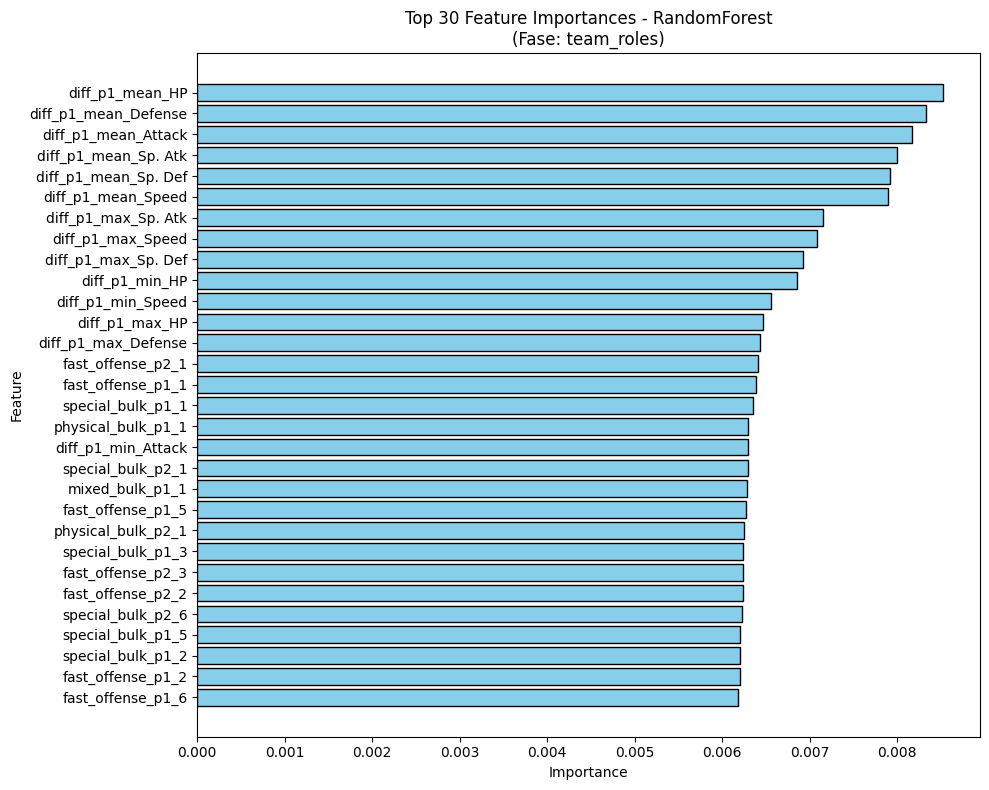

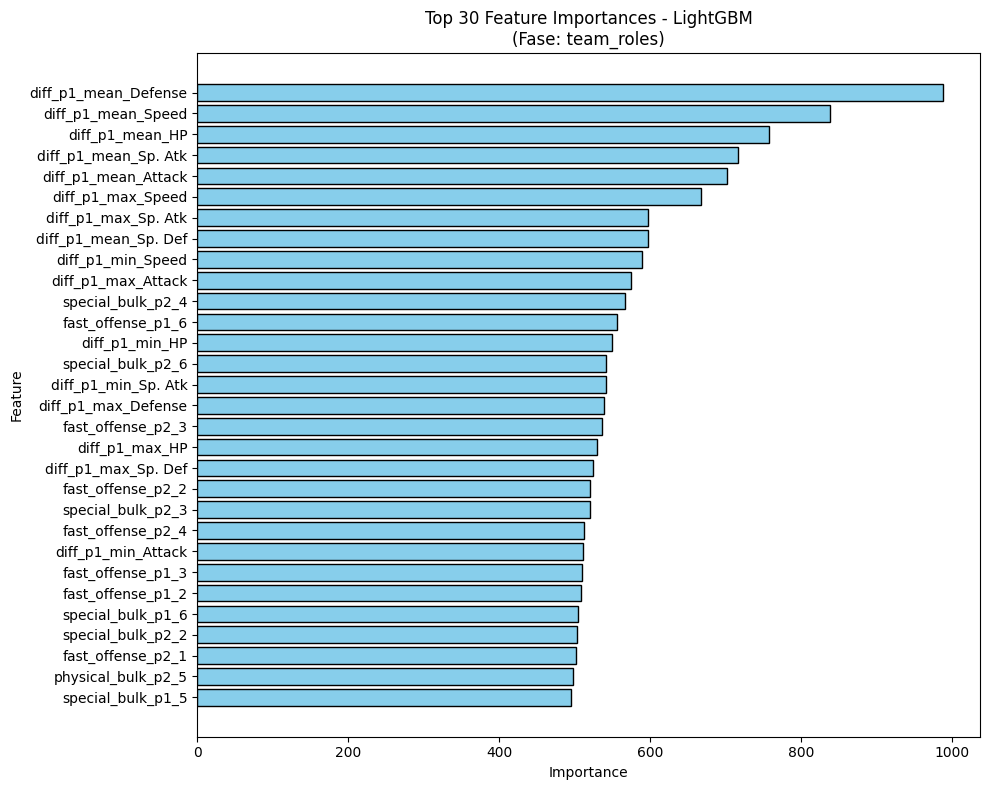

✅ Importancias guardadas en: ../importances/phase_team_roles/


In [35]:
current_feature_names = state["feature_names"]
save_and_plot_importances(state, phase_name, top_n=30, feature_names=current_feature_names)

In [36]:
X_train_current = state["X_train"]
X_val_current = state["X_val"]
X_test_current = state["X_test"]
X_train_current_rf = state["X_train_rf"]

## FASE 5: Estadísticas diferenciales avanzadas

In [37]:
phase_name = "advanced_diff_features"
phase_sequence = ["advanced_diff_features"]

In [38]:
state = run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups=features_groups,
    X_train_current=X_train_current,
    X_val_current=X_val_current,
    X_test_current=X_test_current,
    X_train_current_rf=X_train_current_rf,
    current_feature_names=current_feature_names,
    y_train=y_train, 
    y_val=y_val, 
    y_test=y_test,
    y_train_rf=y_train_rf,
    df_train=df_train,
    df_train_rf=df_train_rf,
    df_val=df_val,
    df_test=df_test,
    n_trials=n_trials,
    train_sample_fraction=rf_train_fraction
)

RUNNING ABLATION PHASE: advanced_diff_features
FEATURE GROUPS: ['advanced_diff_features']
New dense features added (5): ['diff_n_sweepers', 'diff_n_walls', 'diff_sum_top2_fast_offense', 'diff_sum_top2_offense', 'diff_sum_top2_speed']
Total accumulated features: 970

Split sizes:
Train: 1127573 | Train (RF sample): 169135
Validation: 281894 | Test: 352367


[I 2026-05-23 22:21:20,287] A new study created in memory with name: no-name-f05f395f-9d8b-469f-9d9f-dcad2e994d65



Matrix shapes -> Train: (1127573, 970) | Val: (281894, 970)
⏱️ [PASO 1] Construcción y apilado de features: 3.36s

Starting Optuna optimization...
-> Optimizando Random Forest...


[I 2026-05-23 22:25:23,960] Trial 0 finished with value: 0.5499466720654036 and parameters: {'n_estimators': 546, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5499466720654036.
[I 2026-05-23 22:32:08,618] Trial 1 finished with value: 0.5458030804314782 and parameters: {'n_estimators': 828, 'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5499466720654036.
[I 2026-05-23 22:35:56,126] Trial 2 finished with value: 0.548187306470209 and parameters: {'n_estimators': 309, 'max_depth': 32, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.5499466720654036.
[I 2026-05-23 22:57:06,768] Trial 3 finished with value: 0.5517260724375013 and parameters: {'n_estimators': 627, 'max_depth': 35, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.551726072437

⏱️ [PASO 2A] Optuna Random Forest (5 trials): 2527.01s
-> Optimizando LightGBM...


[I 2026-05-23 23:04:50,819] Trial 0 finished with value: 0.563522325217213 and parameters: {'n_estimators': 528, 'learning_rate': 0.18758559194327173, 'num_leaves': 125, 'max_depth': 36, 'min_child_samples': 22, 'subsample': 0.8100040143312441, 'colsample_bytree': 0.9047160395278411}. Best is trial 0 with value: 0.563522325217213.
[I 2026-05-23 23:07:32,783] Trial 1 finished with value: 0.573918904776429 and parameters: {'n_estimators': 892, 'learning_rate': 0.06098679764635032, 'num_leaves': 168, 'max_depth': 26, 'min_child_samples': 21, 'subsample': 0.6772899962530335, 'colsample_bytree': 0.8991382831478223}. Best is trial 1 with value: 0.573918904776429.
[I 2026-05-23 23:09:01,140] Trial 2 finished with value: 0.573840752338816 and parameters: {'n_estimators': 564, 'learning_rate': 0.09482014803162571, 'num_leaves': 122, 'max_depth': 9, 'min_child_samples': 48, 'subsample': 0.9764037220432096, 'colsample_bytree': 0.7609863554214761}. Best is trial 1 with value: 0.573918904776429.
[I

⏱️ [PASO 2B] Optuna LightGBM (5 trials): 626.31s

Best validation ROC-AUC RF: 0.55213
Best validation ROC-AUC LGBM: 0.57538

Training final models with best parameters...
⏱️ [PASO 3A] Entrenamiento final Random Forest: 364.30s
⏱️ [PASO 3B] Entrenamiento final LightGBM: 164.11s

Optimizing classification threshold...
Best threshold RF: 0.50202 (F1: 0.53585)
Best threshold LGBM: 0.50202 (F1: 0.55202)
⏱️ [PASO 4] Optimización de Thresholds: 28.70s

Evaluating on test set and saving results...
Saved artifacts for rf_advanced_diff_features_best_ablation_test
Saved artifacts for lgbm_advanced_diff_features_best_ablation_test
Results appended to ../results/ablation_results.csv
Results appended to ../results/ablation_results.csv
⏱️ [PASO 5] Evaluación y guardado de artefactos: 30.72s

🚀 FASE COMPLETADA EN: 3744.52 segundos (~62.41 minutos)


Alineación perfecta: Se han mapeado correctamente los 970 nombres reales de las features.


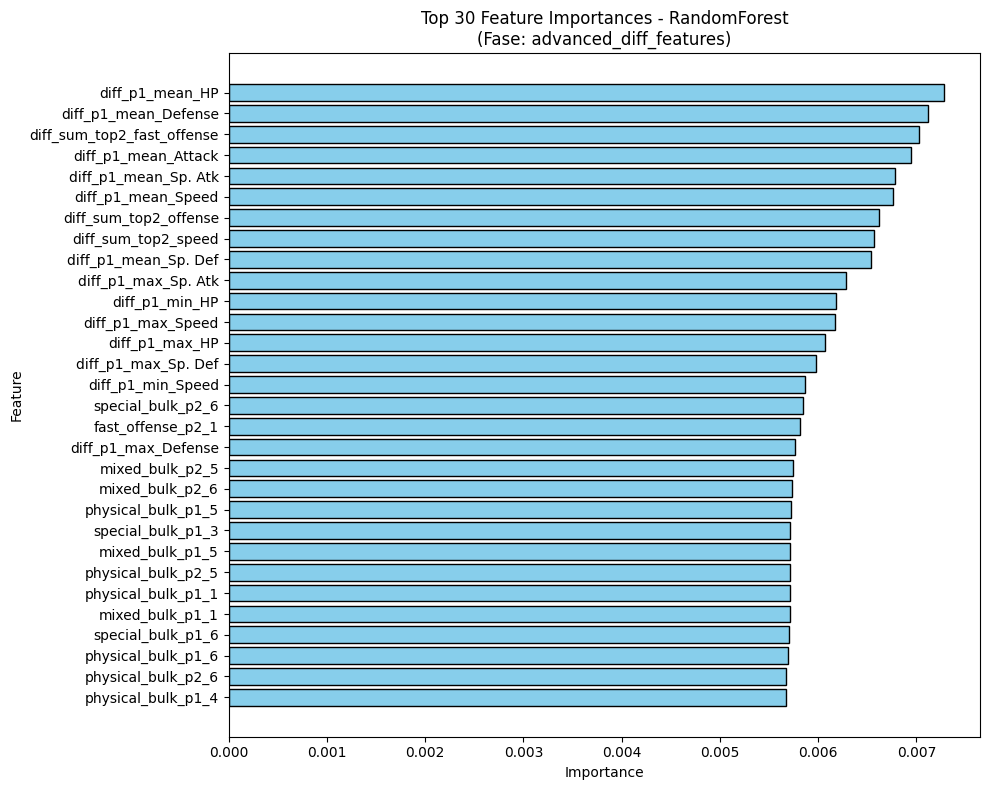

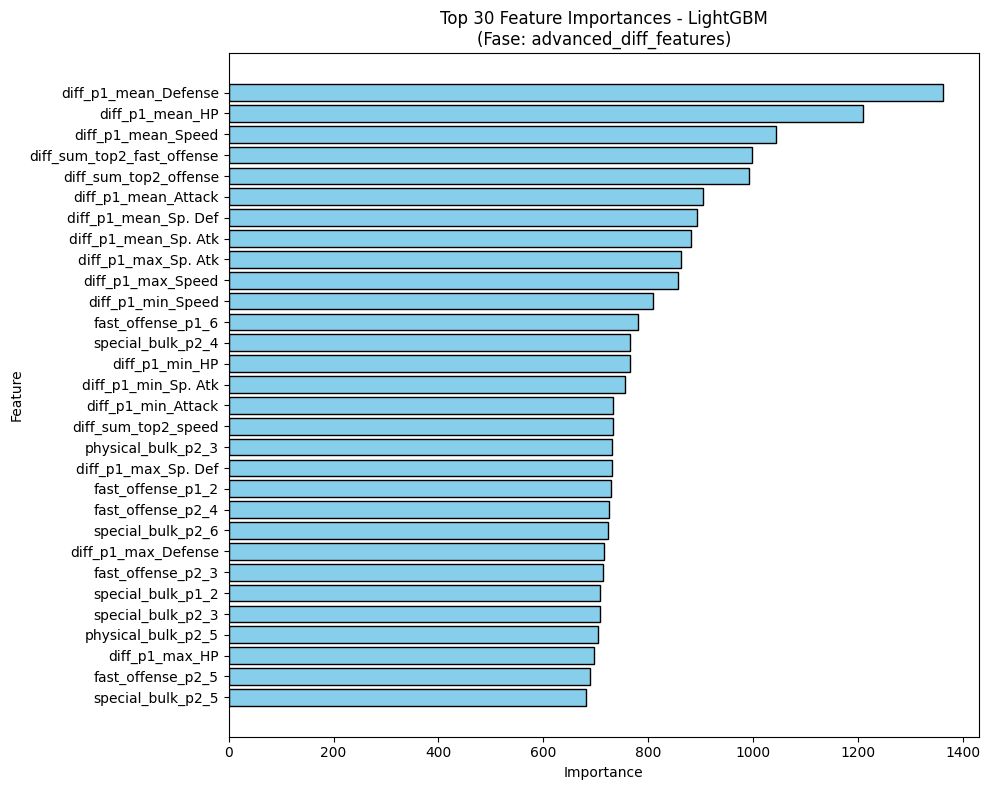

✅ Importancias guardadas en: ../importances/phase_advanced_diff_features/


In [39]:
current_feature_names = state["feature_names"]
save_and_plot_importances(state, phase_name, top_n=30, feature_names=current_feature_names)

In [40]:
X_train_current = state["X_train"]
X_val_current = state["X_val"]
X_test_current = state["X_test"]
X_train_current_rf = state["X_train_rf"]

## FASE 6: Estadísticas de type matchup

In [41]:
phase_name = "type_matchup_features"
phase_sequence = ["type_matchup_features"]

In [42]:
state = run_incremental_ablation_phase(
    phase_name,
    phase_sequence,
    feature_groups=features_groups,
    X_train_current=X_train_current,
    X_val_current=X_val_current,
    X_test_current=X_test_current,
    X_train_current_rf=X_train_current_rf,
    current_feature_names=current_feature_names,
    y_train=y_train, 
    y_val=y_val, 
    y_test=y_test,
    y_train_rf=y_train_rf,
    df_train=df_train,
    df_train_rf=df_train_rf,
    df_val=df_val,
    df_test=df_test,
    n_trials=n_trials,
    train_sample_fraction=rf_train_fraction
)

RUNNING ABLATION PHASE: type_matchup_features
FEATURE GROUPS: ['type_matchup_features']
New dense features added (4): ['diff_best_pressure_sum', 'diff_min_best_response', 'diff_n_not_effective', 'diff_n_super_effective']
Total accumulated features: 974

Split sizes:
Train: 1127573 | Train (RF sample): 169135
Validation: 281894 | Test: 352367


[I 2026-05-23 23:23:46,505] A new study created in memory with name: no-name-de4dfa89-3452-455d-8a40-88b863227808



Matrix shapes -> Train: (1127573, 974) | Val: (281894, 974)
⏱️ [PASO 1] Construcción y apilado de features: 2.60s

Starting Optuna optimization...
-> Optimizando Random Forest...


[I 2026-05-23 23:47:26,337] Trial 0 finished with value: 0.5531237346749859 and parameters: {'n_estimators': 888, 'max_depth': 35, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5531237346749859.
[I 2026-05-23 23:48:14,505] Trial 1 finished with value: 0.5438719960153804 and parameters: {'n_estimators': 420, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.5531237346749859.
[I 2026-05-23 23:50:34,943] Trial 2 finished with value: 0.5410944899573148 and parameters: {'n_estimators': 785, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5531237346749859.
[I 2026-05-24 00:03:59,532] Trial 3 finished with value: 0.5512079561802967 and parameters: {'n_estimators': 794, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.55312373467498

⏱️ [PASO 2A] Optuna Random Forest (5 trials): 2572.55s
-> Optimizando LightGBM...


[I 2026-05-24 00:08:13,666] Trial 0 finished with value: 0.5714883443300088 and parameters: {'n_estimators': 540, 'learning_rate': 0.05830587497148313, 'num_leaves': 64, 'max_depth': 16, 'min_child_samples': 7, 'subsample': 0.9840092746242113, 'colsample_bytree': 0.8758985177196894}. Best is trial 0 with value: 0.5714883443300088.
[I 2026-05-24 00:10:33,602] Trial 1 finished with value: 0.5682384870549977 and parameters: {'n_estimators': 317, 'learning_rate': 0.015496804622117772, 'num_leaves': 196, 'max_depth': 22, 'min_child_samples': 7, 'subsample': 0.9702660627182769, 'colsample_bytree': 0.6298383613893441}. Best is trial 0 with value: 0.5714883443300088.
[I 2026-05-24 00:13:06,238] Trial 2 finished with value: 0.5615662495928926 and parameters: {'n_estimators': 782, 'learning_rate': 0.011349218331628427, 'num_leaves': 30, 'max_depth': 29, 'min_child_samples': 86, 'subsample': 0.8275088543985328, 'colsample_bytree': 0.6970261722027548}. Best is trial 0 with value: 0.571488344330008

⏱️ [PASO 2B] Optuna LightGBM (5 trials): 637.85s

Best validation ROC-AUC RF: 0.55312
Best validation ROC-AUC LGBM: 0.57568

Training final models with best parameters...
⏱️ [PASO 3A] Entrenamiento final Random Forest: 1872.17s
⏱️ [PASO 3B] Entrenamiento final LightGBM: 165.85s

Optimizing classification threshold...
Best threshold RF: 0.50202 (F1: 0.53728)
Best threshold LGBM: 0.50202 (F1: 0.55226)
⏱️ [PASO 4] Optimización de Thresholds: 42.19s

Evaluating on test set and saving results...
Saved artifacts for rf_type_matchup_features_best_ablation_test
Saved artifacts for lgbm_type_matchup_features_best_ablation_test
Results appended to ../results/ablation_results.csv
Results appended to ../results/ablation_results.csv
⏱️ [PASO 5] Evaluación y guardado de artefactos: 49.73s

🚀 FASE COMPLETADA EN: 5342.97 segundos (~89.05 minutos)


Alineación perfecta: Se han mapeado correctamente los 974 nombres reales de las features.


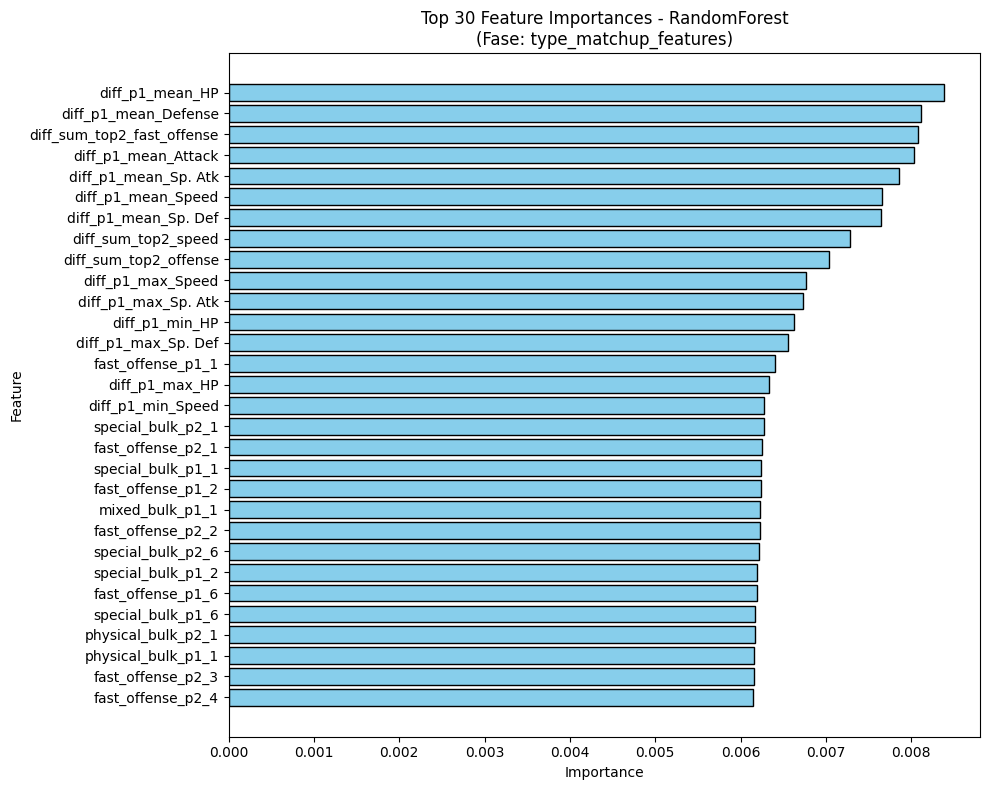

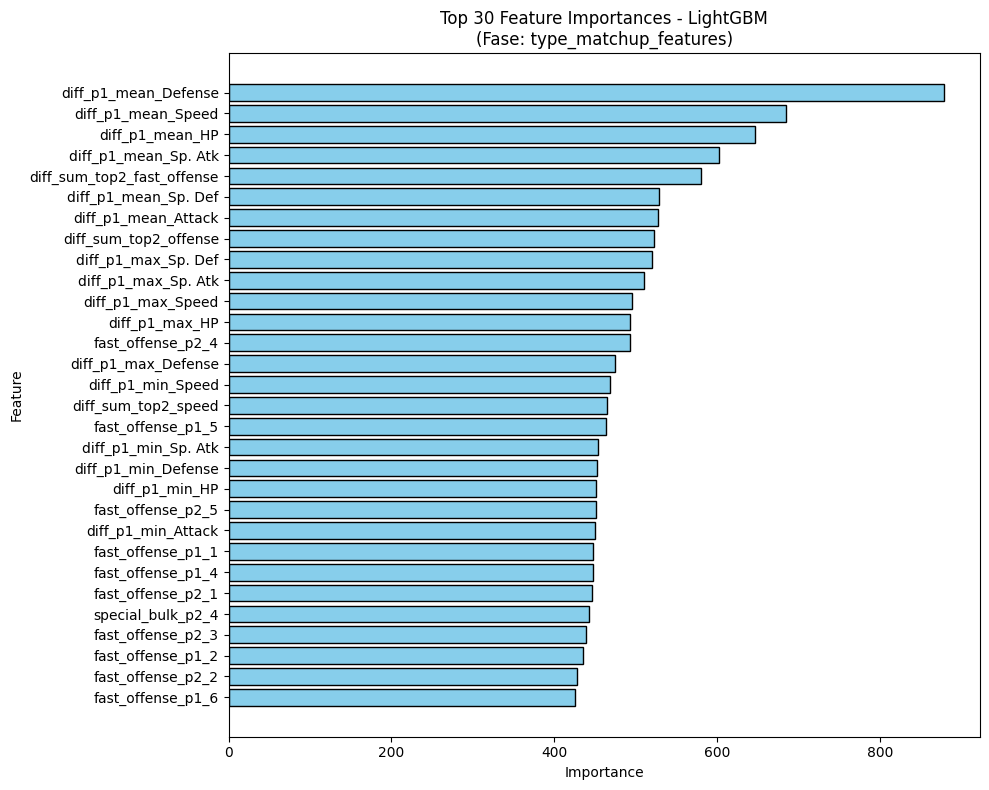

✅ Importancias guardadas en: ../importances/phase_type_matchup_features/


In [43]:
current_feature_names = state["feature_names"]
save_and_plot_importances(state, phase_name, top_n=30, feature_names=current_feature_names)

In [44]:
X_train_current = state["X_train"]
X_val_current = state["X_val"]
X_test_current = state["X_test"]
X_train_current_rf = state["X_train_rf"]

## Análisis de Resultados

### Análisis de importacias en fase final

In [19]:
feature_to_phase = {}
for phase, list_of_feats in features_groups.items():
    for feat in list_of_feats:
        feature_to_phase[feat] = phase

def load_and_process_importances(model_name, filepath):
    if not os.path.exists(filepath):
        print(f"❌ Archivo no encontrado: {filepath}")
        return None
        
    df = pd.read_csv(filepath)
    
    # Asignar fase. Si no existe en el JSON, pertenece a las 807 features iniciales
    df['Phase'] = df['Feature'].map(feature_to_phase).fillna('Pokemon_Names')
    df['Model'] = model_name
    return df

path_rf = "../importances/phase_type_matchup_features/randomforest_importances.csv"
path_lgbm = "../importances/phase_type_matchup_features/lightgbm_importances.csv"

df_rf = load_and_process_importances("RandomForest", path_rf)
df_lgbm = load_and_process_importances("LightGBM", path_lgbm)

# Combinar en un único DataFrame maestro para el análisis analítico
df_all_importances = pd.concat([df_rf, df_lgbm], ignore_index=True)

print(f"Datos cargados correctamente.")
print(f"Filas mapeadas -> RF: {len(df_rf) if df_rf is not None else 0} | LGBM: {len(df_lgbm) if df_lgbm is not None else 0}")
df_all_importances.head()

Datos cargados correctamente.
Filas mapeadas -> RF: 974 | LGBM: 974


,Feature,Importance,Phase,Model
0,diff_p1_mean_HP,0.008388,basic_diff_stats,RandomForest
1,diff_p1_mean_Defense,0.008121,basic_diff_stats,RandomForest
2,diff_sum_top2_fast_offense,0.008084,advanced_diff_features,RandomForest
3,diff_p1_mean_Attack,0.008039,basic_diff_stats,RandomForest
4,diff_p1_mean_Sp. Atk,0.007857,basic_diff_stats,RandomForest


Visualización de importancias de características en fase final, con agrupación por fases.

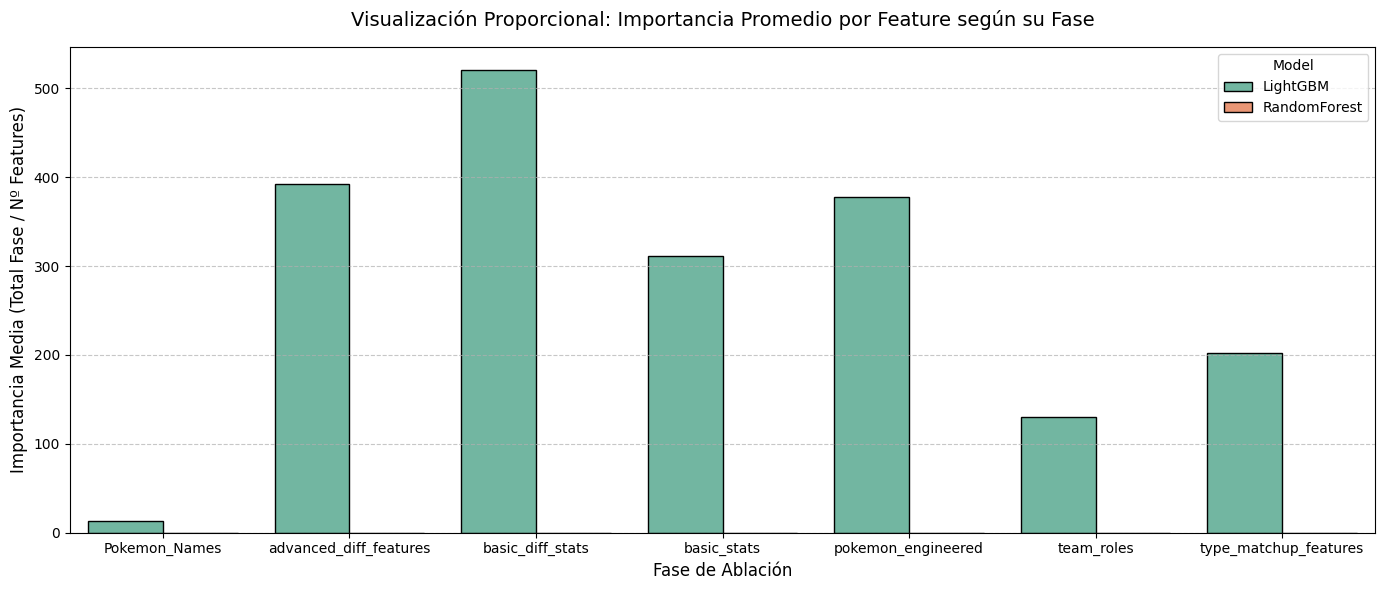

In [21]:
phase_analysis = df_all_importances.groupby(['Model', 'Phase']).agg(
    total_importance=('Importance', 'sum'),
    num_features=('Importance', 'count')
).reset_index()

# Importancia proporcional (media por feature en esa fase)
phase_analysis['proportional_importance'] = phase_analysis['total_importance'] / phase_analysis['num_features']


phase_analysis['total_importance_pct'] = phase_analysis.groupby('Model')['total_importance'].transform(lambda x: x * 100)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=phase_analysis, 
    x='Phase', 
    y='proportional_importance', 
    hue='Model', 
    palette='Set2',
    edgecolor='black'
)
plt.title("Visualización Proporcional: Importancia Promedio por Feature según su Fase", fontsize=14, pad=15)
plt.ylabel("Importancia Media (Total Fase / Nº Features)", fontsize=12)
plt.xlabel("Fase de Ablación", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

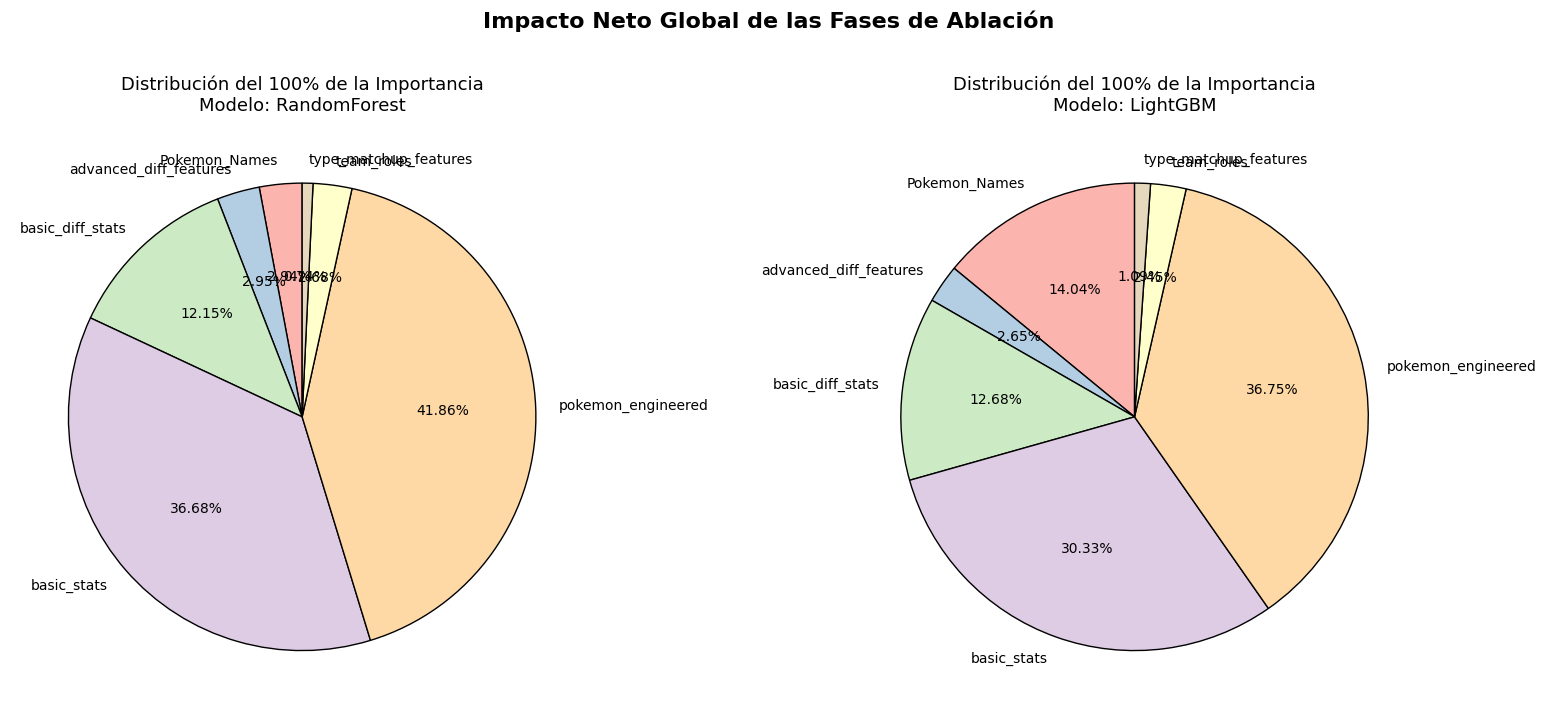

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, model in enumerate(df_all_importances['Model'].unique()):
    data_pie = phase_analysis[phase_analysis['Model'] == model]
    
    axes[i].pie(
        data_pie['total_importance_pct'], 
        labels=data_pie['Phase'], 
        autopct='%1.2f%%',
        startangle=90,
        colors=sns.color_palette('Pastel1', len(data_pie)),
        wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True}
    )
    axes[i].set_title(f"Distribución del 100% de la Importancia\nModelo: {model}", fontsize=13, pad=10)

plt.suptitle("Impacto Neto Global de las Fases de Ablación", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()